In [57]:
import os, sys

sys.path.append(os.path.abspath("../"))


In [58]:
from qiskit import QuantumCircuit, QuantumRegister

import rustworkx
from rustworkx.visualization import graphviz_draw
from rustworkx.rustworkx import simple_cycles
import collections
from collections import Counter
import copy


In [59]:
from helperfunctions.reversecircuitgraph import uncompute_input_nodes_greedy, add_uncomp_input_node, uncomp_all_operations_using_bennetts_in_circuitgraph
from helperfunctions.circuitgraphfunctions import get_computation_graph, get_uncomp_circuit
from helperfunctions.graphhelper import breakdown_qubit, edge_attr, node_attr
from helperfunctions.uncompfunctions import add_uncomputation, add_uncomputation_step, exhaustive_uncomputation
from helperfunctions.randomcircuit import get_qubits_of_circuit
from helperfunctions.constants import StringConstants, ListConstants

In [60]:
INPUT = StringConstants.INPUT.value
ANCILLA = StringConstants.ANCILLA.value
OUTPUT = StringConstants.OUTPUT.value

INIT = StringConstants.INIT.value
COMP = StringConstants.COMP.value
UNCOMP = StringConstants.UNCOMP.value

TARGET = StringConstants.TARGET.value
CONTROL = StringConstants.CONTROL.value
ANTIDEP = StringConstants.ANTIDEP.value

NON_QFREE = ListConstants.NON_QFREE.value

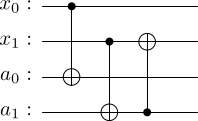

In [ ]:
circ1 = QuantumCircuit(QuantumRegister(2,'x'), QuantumRegister(2,'a'))
circ1.cx(0,2)
circ1.cx(1,3)
circ1.ccx(3,2,1)
circ1.draw('latex')

['a0', 'a1']


Adding Nodes for Circuit: 100%|██████████| 3/3 [00:00<00:00, 17848.10it/s]


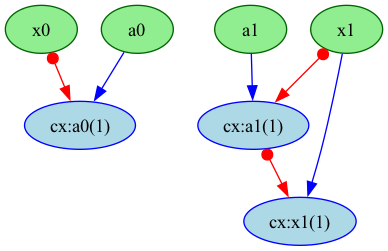

In [62]:
an1 = get_qubits_of_circuit(circ1, 2, ANCILLA)
print(an1)
cg1 = get_computation_graph(circ1, an1)

graphviz_draw(cg1, node_attr, edge_attr)

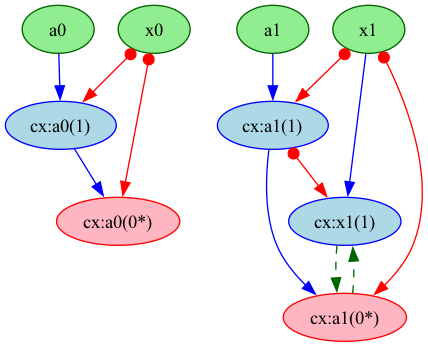

In [63]:
ucg1, cycle = add_uncomputation(cg1, an1, allow_cycle=True)

graphviz_draw(ucg1, node_attr, edge_attr)

In [64]:
eucg1 = exhaustive_uncomputation(cg1, an1)

Checking Out Exhaustive Uncomp for All Ancillas: 4it [00:00, 3057.63it/s]


Building uncomp circuit from circuit graph: 100%|██████████| 8/8 [00:00<00:00, 53008.58it/s]


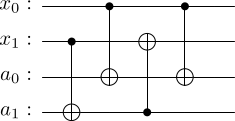

In [65]:
ucirc1 = get_uncomp_circuit(eucg1)
ucirc1.draw('latex')